Index(['Date', 'Rain', 'Temp Max', 'Temp Min', 'Location', 'Rain.1',
       'Temp Max.1', 'Temp Min.1', 'Location.1'],
      dtype='str')


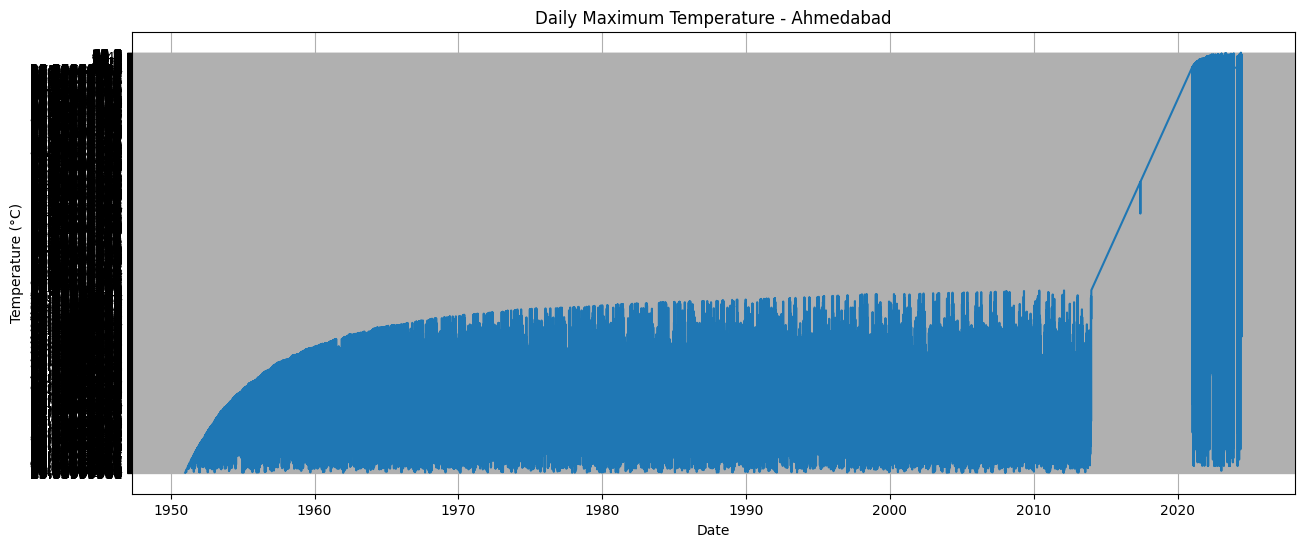

In [9]:
'''Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.'''

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ahmedabad_daily_temperature.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check column names
print(df.columns)

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

# Sort by date
df = df.sort_values("Date")

# Plot raw daily maximum temperature
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Temp Max"]
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Maximum Temperature - Ahmedabad")
plt.grid(True)

plt.show()

In [10]:
'''Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.'''

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("ahmedabad_daily_temperature.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

# Sort by date
df = df.sort_values("Date")

# Set Date as index
df.set_index("Date", inplace=True)

# Select maximum temperature
temperature = df["Temp Max"]

# Decompose the time series
result = seasonal_decompose(
    temperature,
    model="additive",
    period=365
)

# Plot Observed component
plt.figure(figsize=(14, 5))
plt.plot(result.observed)
plt.title("Observed Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

# Plot Trend component
plt.figure(figsize=(14, 5))
plt.plot(result.trend)
plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

# Plot Seasonal component
plt.figure(figsize=(14, 5))
plt.plot(result.seasonal)
plt.title("Seasonal Component")
plt.xlabel("Date")
plt.ylabel("Seasonality")
plt.grid(True)
plt.show()

# Plot Residual component
plt.figure(figsize=(14, 5))
plt.plot(result.resid)
plt.title("Residual Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

ValueError: could not convert string to float: '-----'

In [12]:
'''Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.<br><br><em><strong>Hint:</strong> If the p-value is less than 0.05, the series is likely stationary.</em>'''

import pandas as pd
from statsmodels.tsa.stattools import adfuller

# Load dataset
df = pd.read_csv("ahmedabad_daily_temperature.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

# Sort by date
df = df.sort_values("Date")

# Convert temperature column to numeric
# "-----" will become NaN
df["Temp Max"] = pd.to_numeric(
    df["Temp Max"],
    errors="coerce"
)

# Remove missing values
temperature = df["Temp Max"].dropna()

# ADF test
result = adfuller(temperature)

# Print results
print("ADF Test Statistic:", result[0])
print("p-value:", result[1])

# Check stationarity
if result[1] < 0.05:
    print("The temperature series is stationary.")
else:
    print("The temperature series is not stationary.")

ADF Test Statistic: -21.602128204263032
p-value: 0.0
The temperature series is stationary.


C:\Users\Rdvel\AppData\Local\Temp\ipykernel_9900\1786433165.py:32: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(temperature)


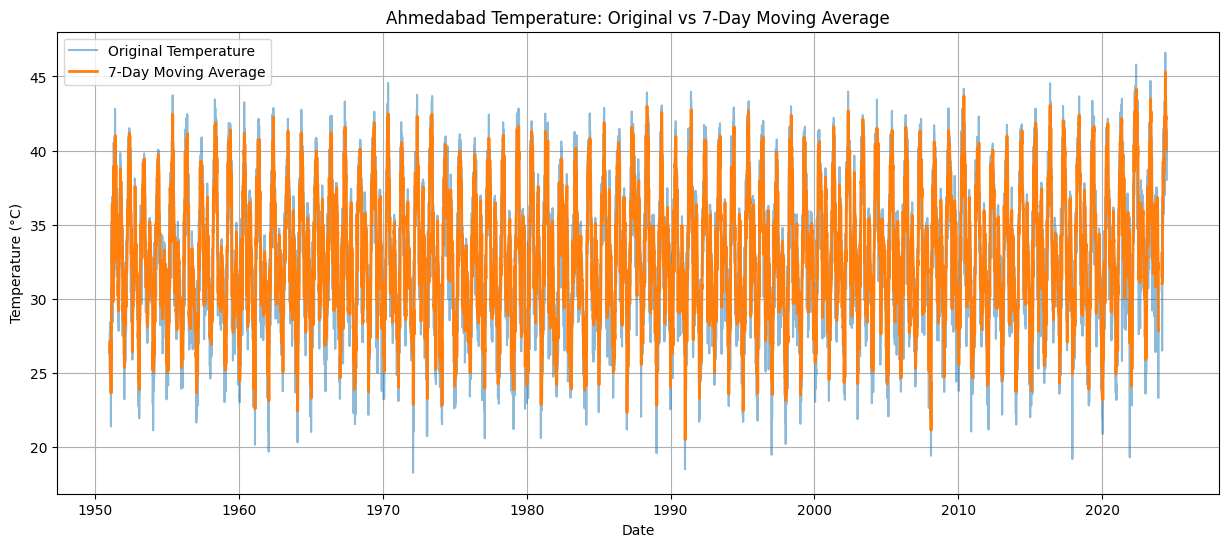

In [13]:
'''Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.'''

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ahmedabad_daily_temperature.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

# Convert temperature to numeric
# "-----" becomes NaN
df["Temp Max"] = pd.to_numeric(
    df["Temp Max"],
    errors="coerce"
)

# Sort by date
df = df.sort_values("Date")

# Calculate 7-day moving average
df["Moving_Average_7"] = df["Temp Max"].rolling(
    window=7
).mean()

# Plot original and smoothed series
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Temp Max"],
    label="Original Temperature",
    alpha=0.5
)

plt.plot(
    df["Date"],
    df["Moving_Average_7"],
    label="7-Day Moving Average",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Ahmedabad Temperature: Original vs 7-Day Moving Average")
plt.legend()
plt.grid(True)

plt.show()